# Exploration of ASSISTments 2009 dataset



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## import dataset
import pandas as pd

path = "/content/drive/MyDrive/education-ml-research/ASSISTments2009/skill_builder_data.csv"

df = pd.read_csv(path, encoding='latin1')

/tmp/ipykernel_1272/2314197327.py:6: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding='latin1')


In [3]:
## Display first few rows of dataset
df.head()


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [4]:
df.info()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525534 entries, 0 to 525533
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              525534 non-null  int64  
 1   assignment_id         525534 non-null  int64  
 2   user_id               525534 non-null  int64  
 3   assistment_id         525534 non-null  int64  
 4   problem_id            525534 non-null  int64  
 5   original              525534 non-null  int64  
 6   correct               525534 non-null  int64  
 7   attempt_count         525534 non-null  int64  
 8   ms_first_response     525534 non-null  int64  
 9   tutor_mode            525534 non-null  object 
 10  answer_type           525534 non-null  object 
 11  sequence_id           525534 non-null  int64  
 12  student_class_id      525534 non-null  int64  
 13  position              525534 non-null  int64  
 14  type                  525534 non-null  object 
 15  

Index(['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id',
       'original', 'correct', 'attempt_count', 'ms_first_response',
       'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id',
       'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name',
       'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time',
       'template_id', 'answer_id', 'answer_text', 'first_action',
       'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='object')

## Exploring the dataset

In [5]:
num_students = df["user_id"].nunique()

print(f"Number of students: {num_students}")


num_skills = df["skill_id"].nunique()

print(f"Number of skills: {num_skills}")


## Attempts per student
attempts = df.groupby("user_id").size()

attempts.describe()

Number of students: 4217
Number of skills: 123


,0
count,4217.000000
mean,124.622718
std,307.594047
min,1.000000
25%,10.000000
50%,27.000000
75%,95.000000
max,8214.000000


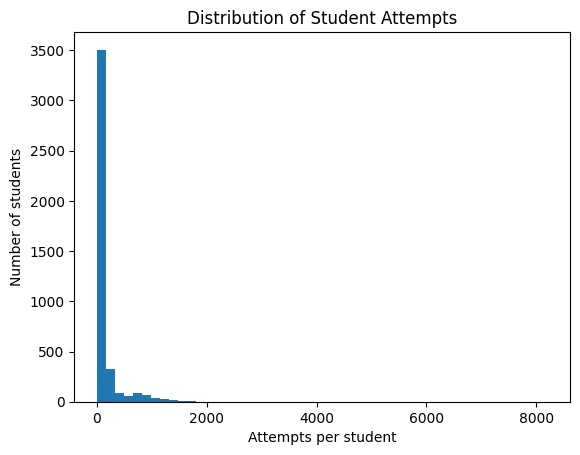

In [6]:
## Visualization of student attempts
import matplotlib.pyplot as plt

plt.hist(attempts, bins=50)
plt.xlabel("Attempts per student")
plt.ylabel("Number of students")
plt.title("Distribution of Student Attempts")
plt.show()

In [7]:
print(f"Number of unique problems: {df["problem_id"].nunique()}")

print(f"Total attempts: {len(df)}")

print(f"Average accuracy: {df["correct"].mean():.4f}")


Number of unique problems: 26688
Total attempts: 525534
Average accuracy: 0.6795


## Skills Data

In [8]:
skill_counts = df["skill_name"].value_counts()

## 10 most practiced skills
print(skill_counts.head(10))
print("")

## 10 least practiced skills
print(skill_counts.tail(10))
print("")


skill_accuracy = (
    df.groupby("skill_name")["correct"]
      .mean()
      .sort_values()
)

## Hardest skills
print(skill_accuracy.head(10))
print("")
## Easiest skills
print(skill_accuracy.tail(10))

skill_name
Equation Solving Two or Fewer Steps         24253
Percent Of                                  22931
Addition and Subtraction Integers           22895
Conversion of Fraction Decimals Percents    20992
Volume Rectangular Prism                    19489
Venn Diagram                                18275
Volume Cylinder                             13734
Multiplication and Division Integers        13159
Area Rectangle                              12934
Addition and Subtraction Fractions          11334
Name: count, dtype: int64

skill_name
Linear Equations                                 89
Percent Discount                                 47
Computation with Real Numbers                    42
Interpreting Coordinate Graphs                   33
Quadratic Formula to Solve Quadratic Equation    32
Midpoint                                         32
Distributive Property                            18
Finding Slope From Situation                      9
Reading a Ruler or Scale           

Overall, there are 4217 students who practiced 123 skills. A few students answered a large majority of questions while the rest answered relatively few questions. The average accuracy throughout the dataset was about 67%.


